# UAV–LiDAR biomass estimation with mapped field trees (R)

This self-contained notebook adapts Fu et al. (2025), *Comparison of UAV-LiDAR-driven biomass estimation approaches in planted forests with different management*, to the Cal Poly arboretum inventory.

It uses the mapped trees for tree-centric calibration, keeps height-only trees available for segmentation and height validation, and excludes trees without defensible biomass from biomass-model fitting. It does **not** silently interpret incomplete footprint sums as complete reference biomass.

Paper: https://doi.org/10.1080/17538947.2025.2576910

### Expected inputs

- UAV point cloud: `.las` or `.laz`
- normalized canopy-height model: `.tif` or `.tiff`
- six 12.5 m-diameter footprint polygons: `.gpkg`, `.shp`, or `.geojson`
- the Excel inventory containing `Footprint Trees` and `Biomass Calcs`
- optional overall arboretum boundary for wall-to-wall prediction

Run cells from top to bottom. The input cell can discover files in one project folder or prompt for each file separately.


## 1. Packages

Install once if needed:

```r
install.packages(c("lidR", "sf", "terra", "dplyr", "purrr", "tidyr", "tibble", "ggplot2", "readxl", "readr", "clue"))
IRkernel::installspec()
```


In [1]:

required_packages <- c("lidR", "sf", "terra", "dplyr", "purrr", "tidyr", "tibble", "ggplot2", "readxl", "readr", "clue")
missing_packages <- setdiff(required_packages, rownames(installed.packages()))
if (length(missing_packages)) stop("Install these packages first: ", paste(missing_packages, collapse = ", "))
suppressPackageStartupMessages({
  library(lidR); library(sf); library(terra); library(dplyr); library(purrr)
  library(tidyr); library(tibble); library(ggplot2); library(readxl); library(readr); library(clue)
})
set.seed(42)


Warning message:
"package 'sf' was built under R version 4.5.3"
Warning message:
"package 'terra' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"
Warning message:
"package 'purrr' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'tibble' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'readxl' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'clue' was built under R version 4.5.3"


## 2. Select files

Select the necessary set-up files 

In [18]:
# ============================================================
# Input selection and analysis settings
# ============================================================

ask <- function(message, default = NULL) {
  prompt <- if (is.null(default)) paste0(message, ": ")
            else paste0(message, " [", default, "]: ")
  answer <- trimws(readline(prompt))
  if (!nzchar(answer) && !is.null(default)) default else answer
}

pick_file <- function(label, exts) {
  filters <- matrix(
    c(paste0(label, " (", paste0("*.", exts, collapse = ";"), ")"),
      paste0("*.", exts, collapse = ";"),
      "All files (*.*)", "*.*"),
    ncol = 2, byrow = TRUE
  )
  path <- utils::choose.files(caption = paste("Select:", label),
                               multi = FALSE, filters = filters, index = 1)
  if (!length(path) || !nzchar(path))
    path <- ask(paste("Paste the full path for", label))

  path <- normalizePath(path, winslash = "/", mustWork = TRUE)
  ext  <- tolower(tools::file_ext(path))
  if (!ext %in% exts)
    stop("Wrong file type for ", label, ". Expected: ", paste0(".", exts, collapse = ", "))
  path
}

pick_boundary <- function() {
  use_gdb <- tolower(ask(
    "Outer boundary stored as a regular file or in a geodatabase? Enter 'file' or 'gdb'", "file"
  )) == "gdb"

  if (!use_gdb)
    return(list(source_type = "file",
                path  = pick_file("Outer area-of-interest boundary", c("gpkg", "shp", "geojson")),
                layer = NA_character_))

  gdb_path <- tryCatch(
    utils::choose.dir(caption = "Select the .gdb folder containing the outer boundary"),
    error = function(e) NA_character_
  )
  if (is.na(gdb_path) || !nzchar(gdb_path))
    gdb_path <- ask("Paste the path to the .gdb folder")

  gdb_path <- normalizePath(gdb_path, winslash = "/", mustWork = TRUE)
  if (tolower(tools::file_ext(gdb_path)) != "gdb")
    stop("Select the folder ending in .gdb, not a file inside it.")

  layers <- sf::st_layers(gdb_path)
  if (!length(layers$name)) stop("No readable spatial layers found in the geodatabase.")

  cat("\nAvailable layers:\n")
  for (i in seq_along(layers$name)) {
    geom <- if (!is.null(layers$geomtype) && length(layers$geomtype) >= i)
              layers$geomtype[i] else "unknown geometry"
    cat(sprintf("  [%d] %s — %s\n", i, layers$name[i], geom))
  }
  flush.console()

  idx <- suppressWarnings(as.integer(ask("Enter the layer number")))
  if (is.na(idx) || idx < 1 || idx > length(layers$name))
    stop("Invalid layer selection.")

  list(source_type = "gdb", path = gdb_path, layer = layers$name[idx])
}

read_boundary <- function(src) {
  sf::st_read(dsn = src$path,
              layer = if (src$source_type == "gdb") src$layer else NULL,
              quiet = TRUE)
}


# ============================================================
# Collect inputs
# ============================================================

lidar_path    <- pick_file("UAV LiDAR point cloud", c("las", "laz"))
chm_path      <- pick_file("Canopy Height Model", c("tif", "tiff"))
workbook_path <- pick_file("Tree inventory workbook (Excel)", "xlsx")
gedi_path     <- pick_file("Clipped GEDI footprints", c("gpkg", "shp", "geojson"))
boundary_src  <- pick_boundary()

aoi <- read_boundary(boundary_src) |> sf::st_make_valid()
if (is.na(sf::st_crs(aoi)))
  stop("The outer boundary has no coordinate reference system.")

output_dir <- file.path(dirname(workbook_path), "uav_biomass_outputs")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)


# ============================================================
# Analysis settings
# ============================================================

cfg <- list(
  expected_footprints         = 6L,
  plot_radius_m               = 12.5,
  plot_diameter_m             = 25,
  mapping_cell_m              = 22.16,   # ~ same area as 25 m-diameter circle
  remove_noise                = TRUE,
  dtm_resolution_m            = 0.4,
  min_tree_height_m           = 2.0,
  treetop_window_m            = 3.0,
  dalponte_th_tree            = 2.0,
  dalponte_th_seed            = 0.45,
  dalponte_th_cr              = 0.55,
  dalponte_max_cr_m           = 10,
  match_max_distance_m        = 4.0,
  match_max_height_difference_m = 8.0,
  match_height_weight         = 0.35
)


# ============================================================
# Confirm selections
# ============================================================

boundary_desc <- if (boundary_src$source_type == "gdb") {
  paste0(boundary_src$path, " | layer: ", boundary_src$layer)
} else {
  boundary_src$path
}

tibble::tibble(
  input = c("UAV LiDAR", "Canopy Height Model", "Tree inventory workbook",
            "GEDI footprints", "Outer boundary", "Output directory"),
  path  = c(lidar_path, chm_path, workbook_path, gedi_path, boundary_desc, output_dir)
)
cfg


Available layers:
  [1] Polygons_2 — 3D Multi Polygon
  [2] treesandgardens_XYTableToPoint — Point
  [3] gedi_arb_points — Point
  [4] gedi_arb_points_Buffer — Multi Polygon
  [5] blob_Buffer — Multi Polygon
  [6] blob_Buffer2 — Multi Polygon
  [7] ZonalSt_gedi_ar1 — NA
  [8] drone_percentile — NA
  [9] percentiles_drone_lidar — NA
  [10] percentiles_dron — NA
  [11] Line — 3D Multi Line String
  [12] arb_blob — 3D Multi Polygon
  [13] redwood_trees — Point
  [14] GEDIFootprints25mDiameter_ExportTable — NA
  [15] GEDIFootprints25mDiameter_ExportFeatures — Multi Polygon
  [16] gedi_arb_points_ExportFeatures — Point
  [17] gedi_arb_points_ExportF_Clip — 3D Point
  [18] GEDI_Footprint_4_trees — Point
  [19] GEDI_Footprint_4_trees__ATTACH — NA
  [20] GEDI_Footprints_tallest_gt_trees1_trees_Merge — Point
  [21] GEDI_Footprints_tallest_gt_trees1_trees_Merge__ATTACH — NA
  [22] GEDI_Footprints_tallest_gt_trees1_trees_Merge1 — Point
  [23] GEDI_Footprints_tallest_gt_trees1_trees_Merge1__ATTAC

input,path
<chr>,<chr>
UAV LiDAR,C:/Users/davisk10/OneDrive - Cal Poly/Tree Biomass Estimation Research - Documents/CODE/25-04-23_Arboretum.las
Canopy Height Model,C:/Users/davisk10/OneDrive - Cal Poly/Tree Biomass Estimation Research - Documents/CODE/chm_1m_clipped.tif
Tree inventory workbook,C:/Users/davisk10/OneDrive - Cal Poly/Tree Biomass Estimation Research - Documents/Arboretum Info/Arb Excel Workbooks/WorkingTrees_Arboretum_Data.xlsx
GEDI footprints,C:/Users/davisk10/OneDrive - Cal Poly/Tree Biomass Estimation Research - Documents/CODE/Notebook_Test1_Arb_Output_Files/arb_bio_test_2_gedi_footprints_clipped.geojson
Outer boundary,C:/Users/davisk10/OneDrive - Cal Poly/Tree Biomass Estimation Research - Documents/CODE/kdavMyProject.gdb | layer: arb_blob
Output directory,C:/Users/davisk10/OneDrive - Cal Poly/Tree Biomass Estimation Research - Documents/Arboretum Info/Arb Excel Workbooks/uav_biomass_outputs


$expected_footprints
[1] 6

$plot_radius_m
[1] 12.5

$plot_diameter_m
[1] 25

$mapping_cell_m
[1] 22.16

$remove_noise
[1] TRUE

$dtm_resolution_m
[1] 0.4

$min_tree_height_m
[1] 2

$treetop_window_m
[1] 3

$dalponte_th_tree
[1] 2

$dalponte_th_seed
[1] 0.45

$dalponte_th_cr
[1] 0.55

$dalponte_max_cr_m
[1] 10

$match_max_distance_m
[1] 4

$match_max_height_difference_m
[1] 8

$match_height_weight
[1] 0.35

## 3. Analysis settings

The defaults are starting values, not universal segmentation parameters. Tune the local-maximum window and Dalponte thresholds against the mapped trees. The paper used Dalponte for a relatively flat managed forest and PTrees for mountainous forest.


In [19]:
cfg <- list(
  expected_footprints = 6L,
  plot_diameter_m = 25,
  lidar_is_normalized = tolower(readline("Is LAS Z already height above ground? y/n: ")) %in% c("y", "yes"),
  remove_noise = TRUE,
  dtm_resolution_m = 0.4,
  min_tree_height_m = 2.0,
  treetop_window_m = 3.0,
  dalponte_th_tree = 2.0,
  dalponte_th_seed = 0.45,
  dalponte_th_cr = 0.55,
  dalponte_max_cr_m = 10,
  match_max_distance_m = 4.0,
  match_max_height_difference_m = 8.0,
  match_height_weight = 0.35,
  mapping_cell_m = 22.16
)
cfg


$expected_footprints
[1] 6

$plot_diameter_m
[1] 25

$lidar_is_normalized
[1] FALSE

$remove_noise
[1] TRUE

$dtm_resolution_m
[1] 0.4

$min_tree_height_m
[1] 2

$treetop_window_m
[1] 3

$dalponte_th_tree
[1] 2

$dalponte_th_seed
[1] 0.45

$dalponte_th_cr
[1] 0.55

$dalponte_max_cr_m
[1] 10

$match_max_distance_m
[1] 4

$match_max_height_difference_m
[1] 8

$match_height_weight
[1] 0.35

$mapping_cell_m
[1] 22.16

## 4. Read and standardize the Excel inventory

The manual/hypsometer fields are treated as reference measurements. Equivalent DBH and biomass are read from `Biomass Calcs`. Manual mapped coordinates (`Lat`, `Long`) are preferred; Working Trees coordinates are the fallback. Multi-stem records are collapsed to one tree record using the workbook's species/tree/footprint identifiers.


In [20]:
needed_sheets <- c("Footprint Trees", "Biomass Calcs")
if (!all(needed_sheets %in% excel_sheets(workbook_path))) stop("Workbook must contain: ", paste(needed_sheets, collapse = ", "))
stem_raw <- read_excel(workbook_path, sheet = "Footprint Trees")
biomass_raw <- read_excel(workbook_path, sheet = "Biomass Calcs")

first_finite <- function(x) {
  x <- suppressWarnings(as.numeric(x))
  x <- x[is.finite(x)]
  if (length(x)) x[1] else NA_real_
}
as_id <- function(x) {
  y <- suppressWarnings(as.numeric(x))
  ifelse(is.finite(y), format(y, scientific = FALSE, trim = TRUE), as.character(x))
}

stem_trees <- stem_raw |>
  filter(!is.na(Species), !is.na(`Tree #`)) |>
  mutate(species_id = as_id(Species), tree_no = as_id(`Tree #`), footprint_id = as_id(Footprint)) |>
  group_by(species_id, tree_no, footprint_id) |>
  summarise(
    n_stems_recorded = n_distinct(`Stem #`),
    manual_lat = first_finite(Lat), manual_lon = first_finite(Long),
    wt_lat = first_finite(WT_latitude), wt_lon = first_finite(WT_longitude),
    common_name = dplyr::first(na.omit(`Species - Common Name`), default = NA_character_),
    .groups = "drop"
  ) |>
  mutate(
    latitude = coalesce(manual_lat, wt_lat),
    longitude = coalesce(manual_lon, wt_lon),
    coordinate_source = case_when(is.finite(manual_lat) & is.finite(manual_lon) ~ "manual_mapped",
                                  is.finite(wt_lat) & is.finite(wt_lon) ~ "working_trees", TRUE ~ "missing")
  )

tree_reference <- biomass_raw |>
  filter(!is.na(`Spec.`), !is.na(Tree), !is.na(Footprint)) |>
  transmute(
    species_id = as_id(`Spec.`), tree_no = as_id(Tree), footprint_id = as_id(Footprint),
    tree_id = paste(species_id, tree_no, footprint_id, sep = "."),
    scientific_name = `Sci. Species Name`,
    equivalent_dbh_manual_m = suppressWarnings(as.numeric(`GT DBH (m)`)),
    height_manual_m = suppressWarnings(as.numeric(`GT Height`)),
    equivalent_dbh_wt_m = suppressWarnings(as.numeric(`WT DBH (m)`)),
    height_wt_m = suppressWarnings(as.numeric(`WT Height`)),
    biomass_manual_kg = suppressWarnings(as.numeric(`Manual Biomass`)),
    biomass_wt_kg = suppressWarnings(as.numeric(`WT Biomass`)),
    allometry_source = `Allo. Eqn. Source / Density`,
    allometry_code = `Allo Eqn. Code / Type`,
    allometry_equation = `Allometric Equation`,
    wood_density_kg_m3 = suppressWarnings(as.numeric(`DW Density`)),
    biomass_note = Notes
  ) |>
  left_join(stem_trees, by = c("species_id", "tree_no", "footprint_id")) |>
  mutate(
    has_height_reference = is.finite(height_manual_m) & height_manual_m > 0,
    has_biomass_reference = is.finite(biomass_manual_kg) & biomass_manual_kg > 0,
    has_coordinates = is.finite(latitude) & is.finite(longitude)
  )

inventory_qc <- tree_reference |>
  summarise(
    n_trees = n(), n_multistem = sum(n_stems_recorded > 1, na.rm = TRUE),
    n_with_coordinates = sum(has_coordinates), n_with_manual_height = sum(has_height_reference),
    n_with_manual_biomass = sum(has_biomass_reference), n_height_only_or_missing_biomass = sum(has_height_reference & !has_biomass_reference)
  )
inventory_qc
tree_reference |> filter(!has_biomass_reference) |> select(tree_id, footprint_id, scientific_name, height_manual_m, biomass_note)


New names:
• `` -> `...33`
• `` -> `...34`
New names:
• `` -> `...6`
• `` -> `...20`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`


n_trees,n_multistem,n_with_coordinates,n_with_manual_height,n_with_manual_biomass,n_height_only_or_missing_biomass
<int>,<int>,<int>,<int>,<int>,<int>
81,23,81,78,66,12


tree_id,footprint_id,scientific_name,height_manual_m,biomass_note
<chr>,<chr>,<chr>,<dbl>,<chr>
11.1.1,1,spec. unk,0.0,"outlier / cannot determine species, no data"
16.4.2,2,Phoenix roebelenii,0.0,"no dbh data on the pgymy date palms, 4 stem"
5.8.2,2,Sequoia sempervirens,6.2,this redwood tree is an outlier to the main circle
20.1.3,3,prunus virginiana var. demissa,4.2,"outlier, no dbh data and no WT data, 10 stems"
27.1.4,4,Arbutus unedo,3.1,"severe lack of data, could also use Cor/Eri/Lau/Etc equation from Chojnacky"
22.2.4,4,cedrus libani ssp. atlantica ‘pendula’,4.0,too small a tree
27.2.4,4,Arbutus unedo,4.3,"14 stems, lack of data"
28.4.4_6,4_6,Laurus nobilis,4.4,"8 stems, lack of data"
31.1.4,4,Vitex agnus-castus,3.3,"used general equation, too many bees, no stem count or DBH data"


## 5. Load the six footprints and construct mapped tree points

The footprint layer must contain six polygons. Select its footprint-ID column when prompted. IDs should correspond to the workbook's `Footprint` values 1–6. Nonstandard memberships such as `4_6` are flagged and excluded from single-footprint totals unless resolved by the user.


Footprints are in geographic CRS; reprojecting to UTM zone 10 (north).



coordinate_source,agrees,n
<chr>,<lgl>,<int>
manual_mapped,FALSE,2
manual_mapped,TRUE,65
manual_mapped,NA,15


Warning message:
"st_centroid assumes attributes are constant over geometries"


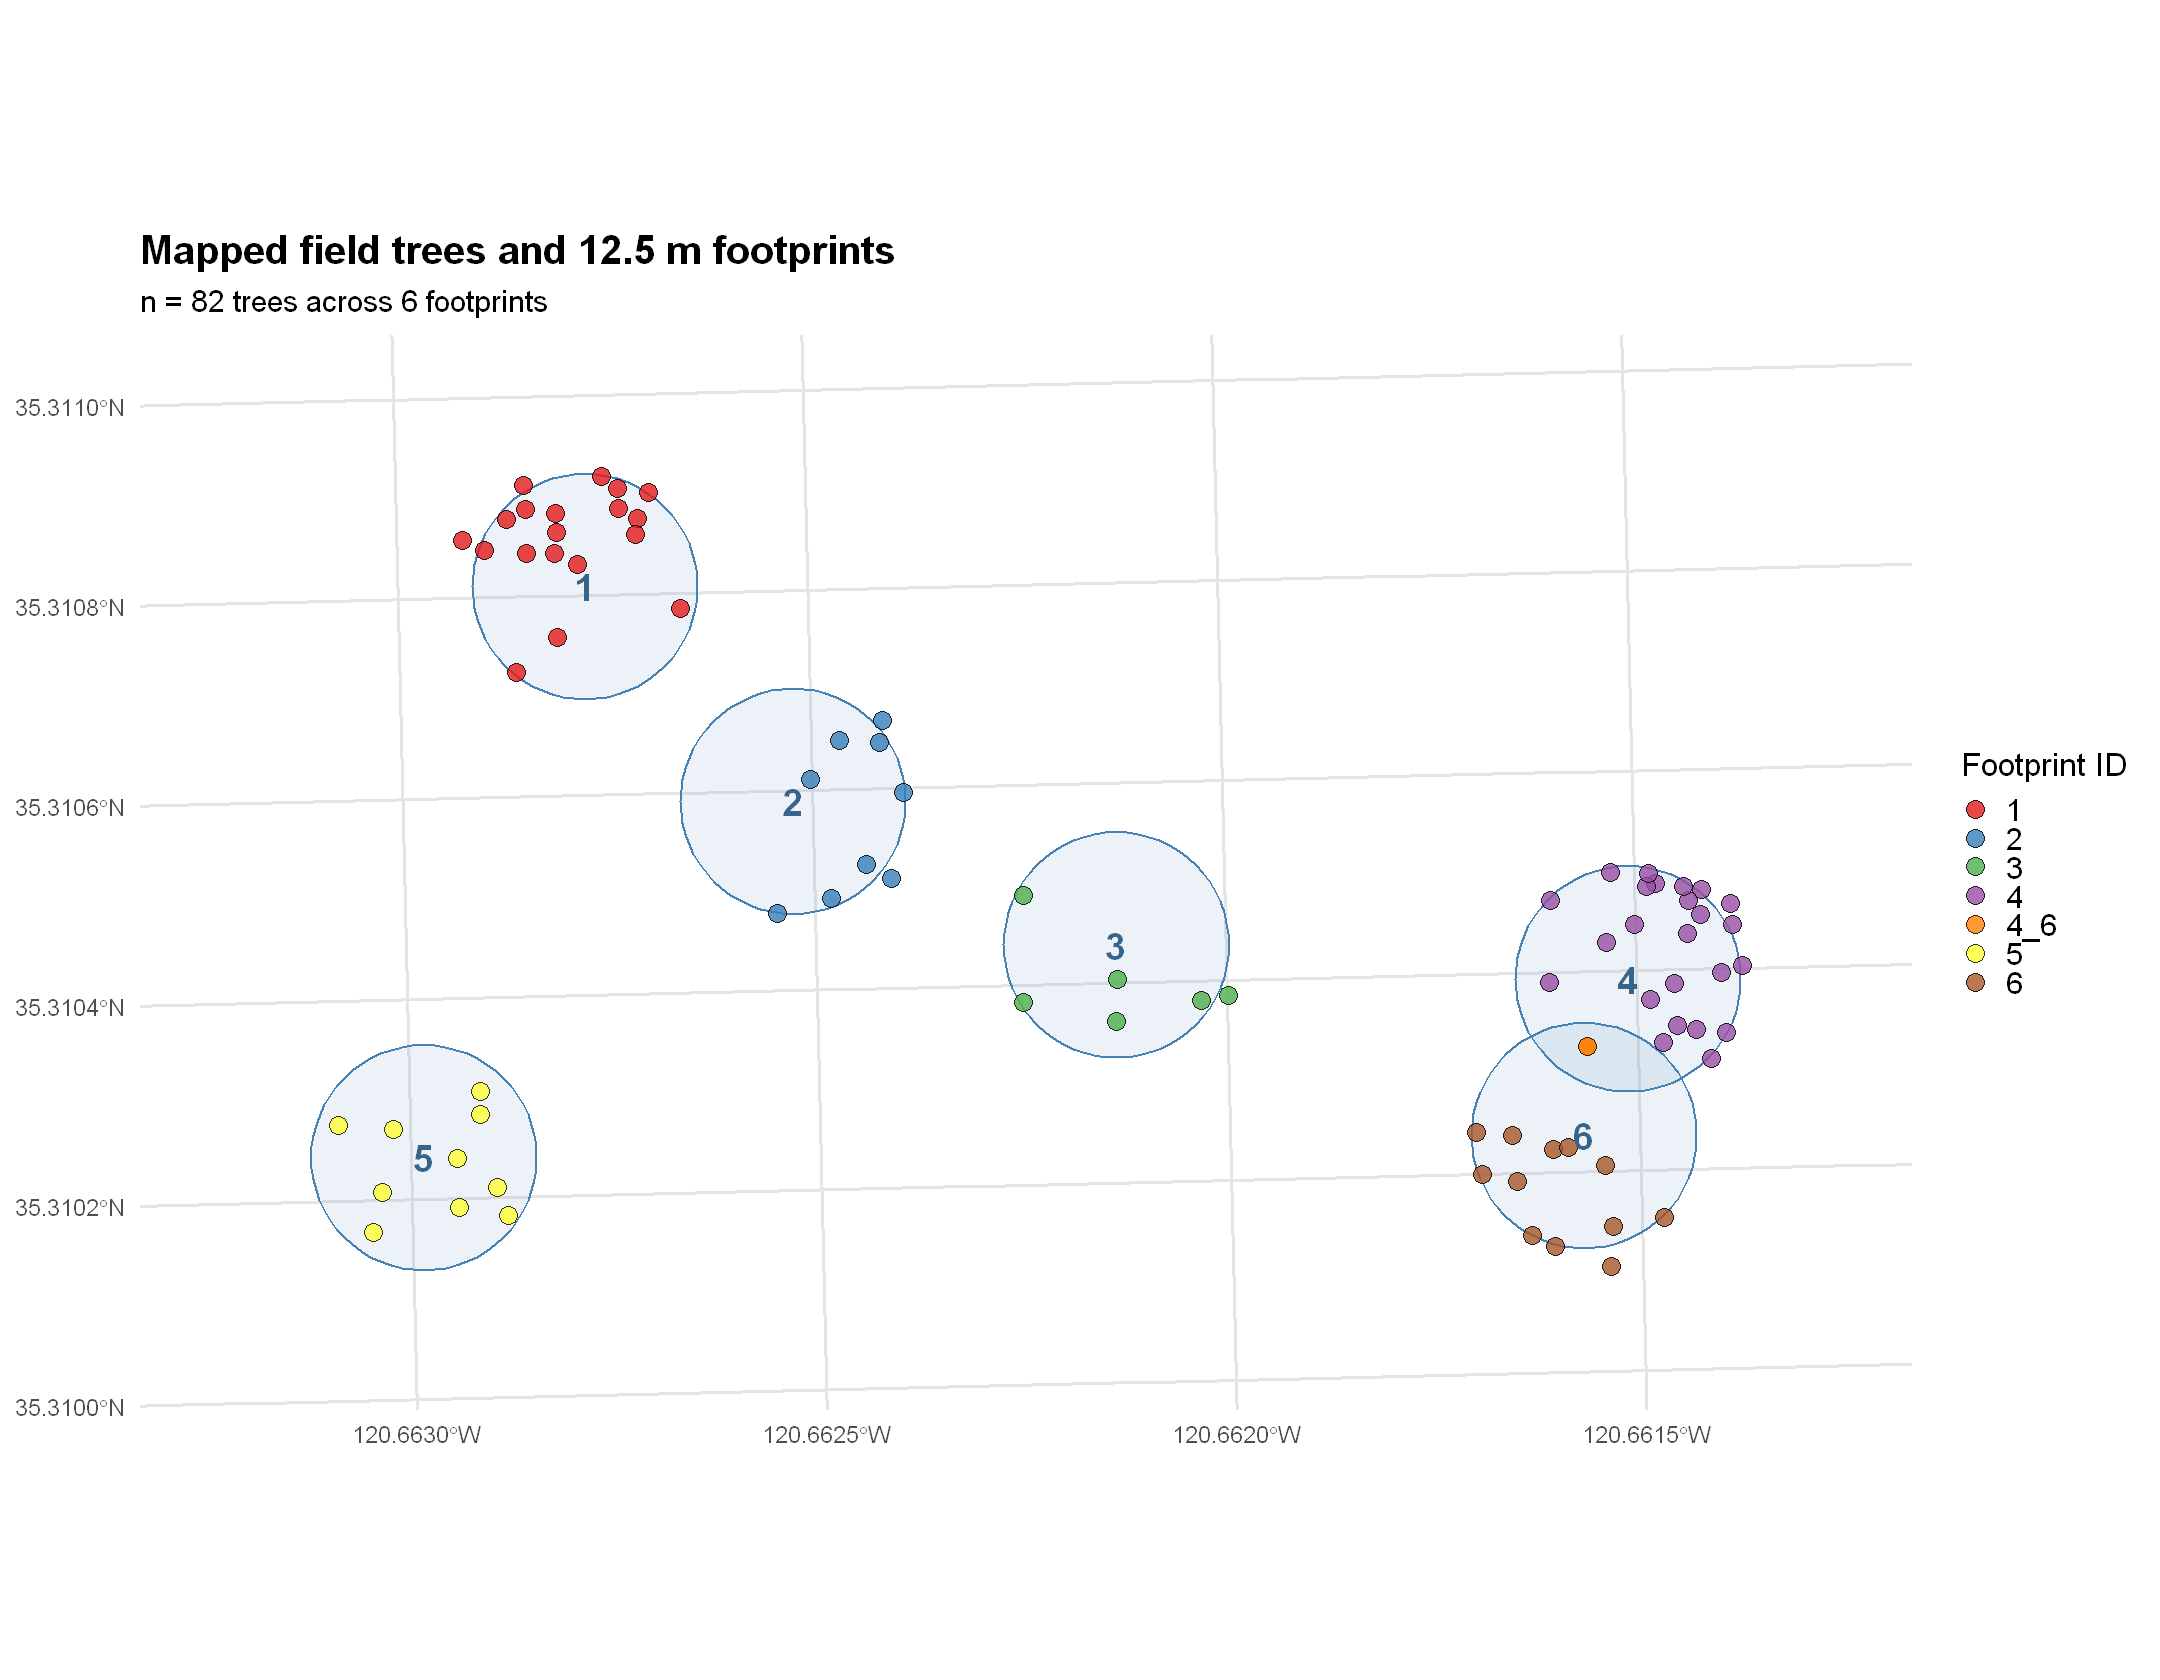

In [37]:
footprints_path <- gedi_path
footprints <- st_read(footprints_path, quiet = TRUE) |> st_make_valid()
if (nrow(footprints) != cfg$expected_footprints) stop("Expected exactly six footprint polygons; found ", nrow(footprints), ".")
if (is.na(st_crs(footprints))) stop("Footprint layer has no CRS.")
if (st_is_longlat(footprints)) {
  utm_zone <- floor((st_bbox(footprints)[["xmin"]] + 180) / 6) + 1
  hemisphere <- if (st_bbox(footprints)[["ymin"]] >= 0) "north" else "south"
  utm_crs <- st_crs(paste0("+proj=utm +zone=", utm_zone, " +", hemisphere, " +datum=WGS84 +units=m"))
  message("Footprints are in geographic CRS; reprojecting to UTM zone ", utm_zone, " (", hemisphere, ").")
  footprints <- st_transform(footprints, utm_crs)
}

if (!"reading_order_id" %in% names(footprints)) stop("Expected a 'reading_order_id' column in the footprints layer but didn't find one.")
footprints$footprint_id <- as_id(footprints$reading_order_id)
if (anyDuplicated(footprints$footprint_id)) stop("Footprint IDs must be unique.")
footprints$area_m2 <- as.numeric(st_area(footprints))
if (anyDuplicated(footprints$footprint_id)) stop("Footprint IDs must be unique.")
footprints$area_m2 <- as.numeric(st_area(footprints))
expected_area <- pi * (cfg$plot_diameter_m / 2)^2
if (any(abs(footprints$area_m2 - expected_area) / expected_area > 0.10)) warning("At least one footprint area differs from a 12.5 m circle by more than 10%.")

if (sum(tree_reference$has_coordinates) < 2) stop("Too few mapped tree coordinates.")
tree_points <- tree_reference |>
  filter(has_coordinates) |>
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326, remove = FALSE) |>
  st_transform(st_crs(footprints))

spatial_membership <- st_join(tree_points, footprints |> select(spatial_footprint_id = footprint_id), join = st_within, left = TRUE)
membership_qc <- spatial_membership |>
  st_drop_geometry() |>
  mutate(agrees = footprint_id == spatial_footprint_id) |>
  count(coordinate_source, agrees, name = "n")
membership_qc

# Zoom to footprint bounding box with a small buffer
bbox_buf <- st_buffer(st_union(footprints), 10)  # 50 m buffer around all footprints
options(repr.plot.width = 18, repr.plot.height = 14)
ggplot() +
  geom_sf(data = footprints, fill = alpha("steelblue", 0.1), colour = "steelblue", linewidth = 0.8) +
  geom_sf(data = spatial_membership, aes(fill = footprint_id), size = 5, alpha = 0.8, shape = 21, color = "black", stroke = 0.5) +
  geom_sf_text(data = st_centroid(footprints), aes(label = footprint_id),
               size = 8, fontface = "bold", colour = "steelblue4") +
  coord_sf(xlim = c(st_bbox(bbox_buf)["xmin"], st_bbox(bbox_buf)["xmax"]),
           ylim = c(st_bbox(bbox_buf)["ymin"], st_bbox(bbox_buf)["ymax"])) +
  scale_fill_brewer(palette = "Set1") +
  labs(title = "Mapped field trees and 12.5 m footprints",
       subtitle = paste0("n = ", nrow(spatial_membership), " trees across ", nrow(footprints), " footprints"),
       fill = "Footprint ID",
       x = NULL, y = NULL) +
  theme_minimal(base_size = 20) +
  theme(legend.position = "right",
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 19),
        plot.title = element_text(size = 24, face = "bold"),
        plot.subtitle = element_text(size = 18),
        axis.text = element_text(size = 14),
        panel.grid.major = element_line(colour = "grey90"))

## 6. Load CHM and preprocess LiDAR

The provided CHM is used for treetop detection and Dalponte segmentation. If LAS Z is not normalized, this cell applies SOR noise classification, CSF ground classification, a 0.4 m DTM, and height normalization.


Chunk 1 of 6 (16.7%): state ✓
Chunk 2 of 6 (33.3%): state ✓                                                   
Chunk 3 of 6 (50%): state ✓                                                     
Chunk 4 of 6 (66.7%): state ✓                                                   
Chunk 5 of 6 (83.3%): state ✓                                                   
Chunk 6 of 6 (100%): state ✓                                                    
Preprocessed returns: 4,418,717 ===============================================] 100% (4 threads)


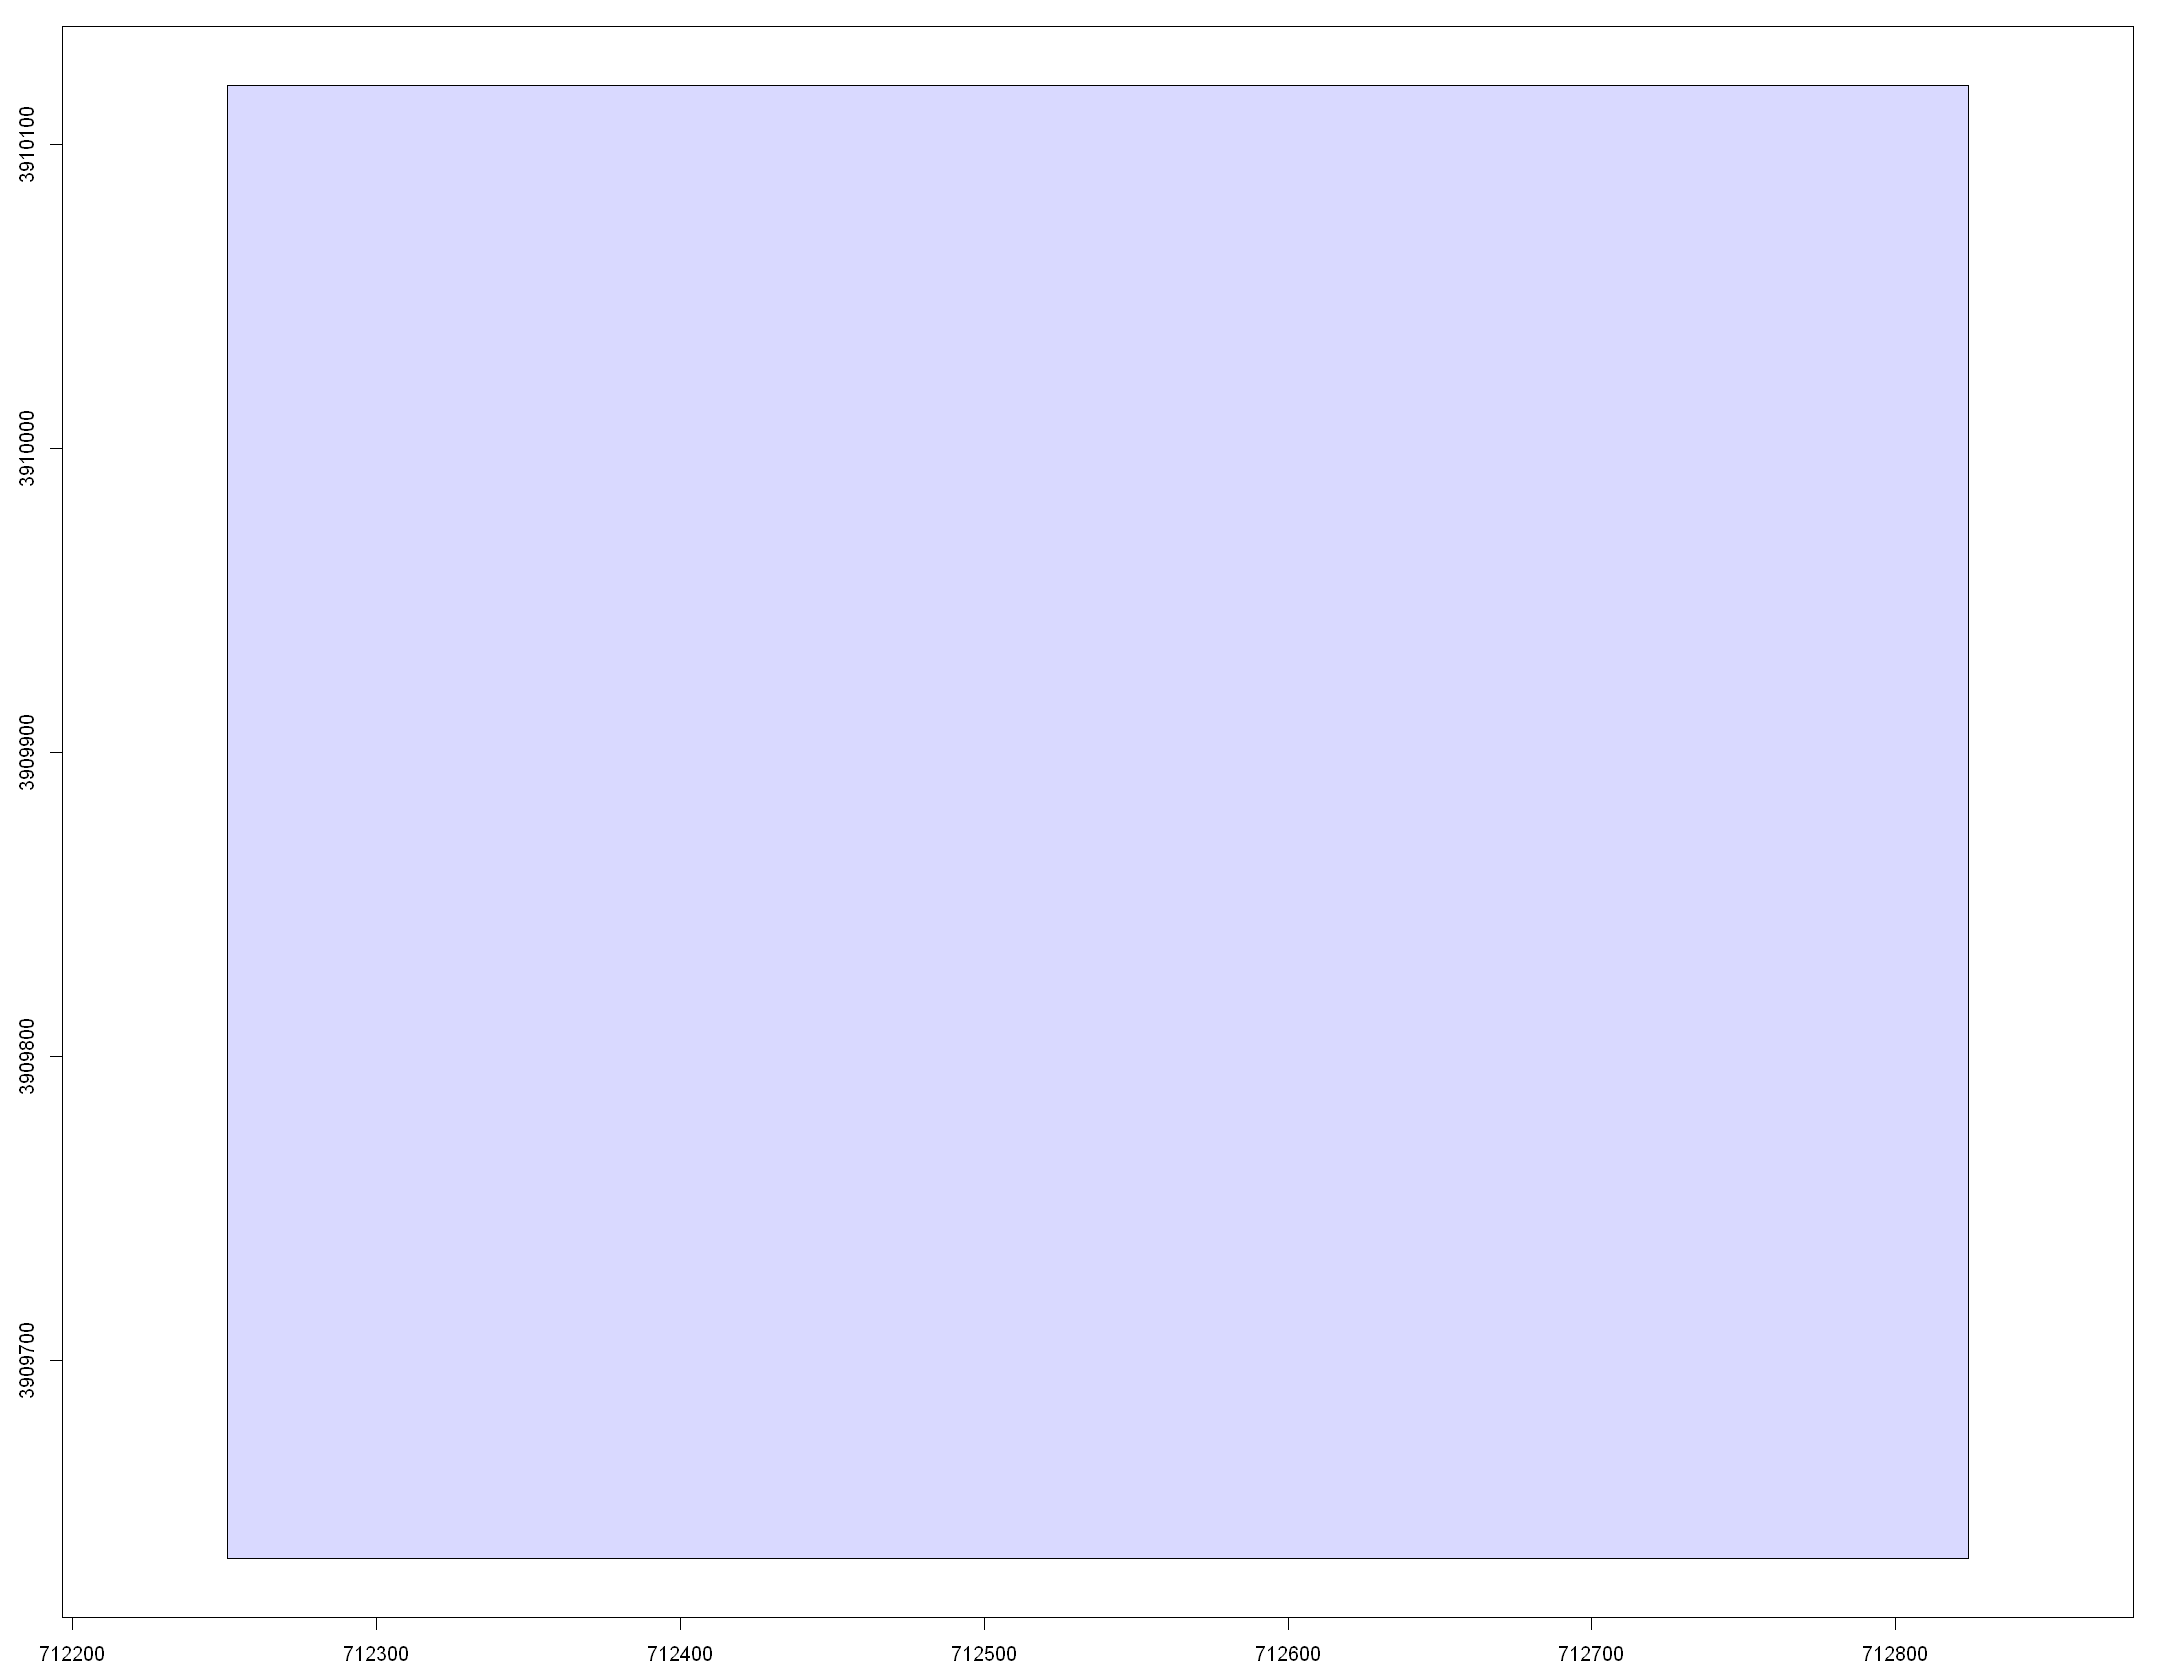

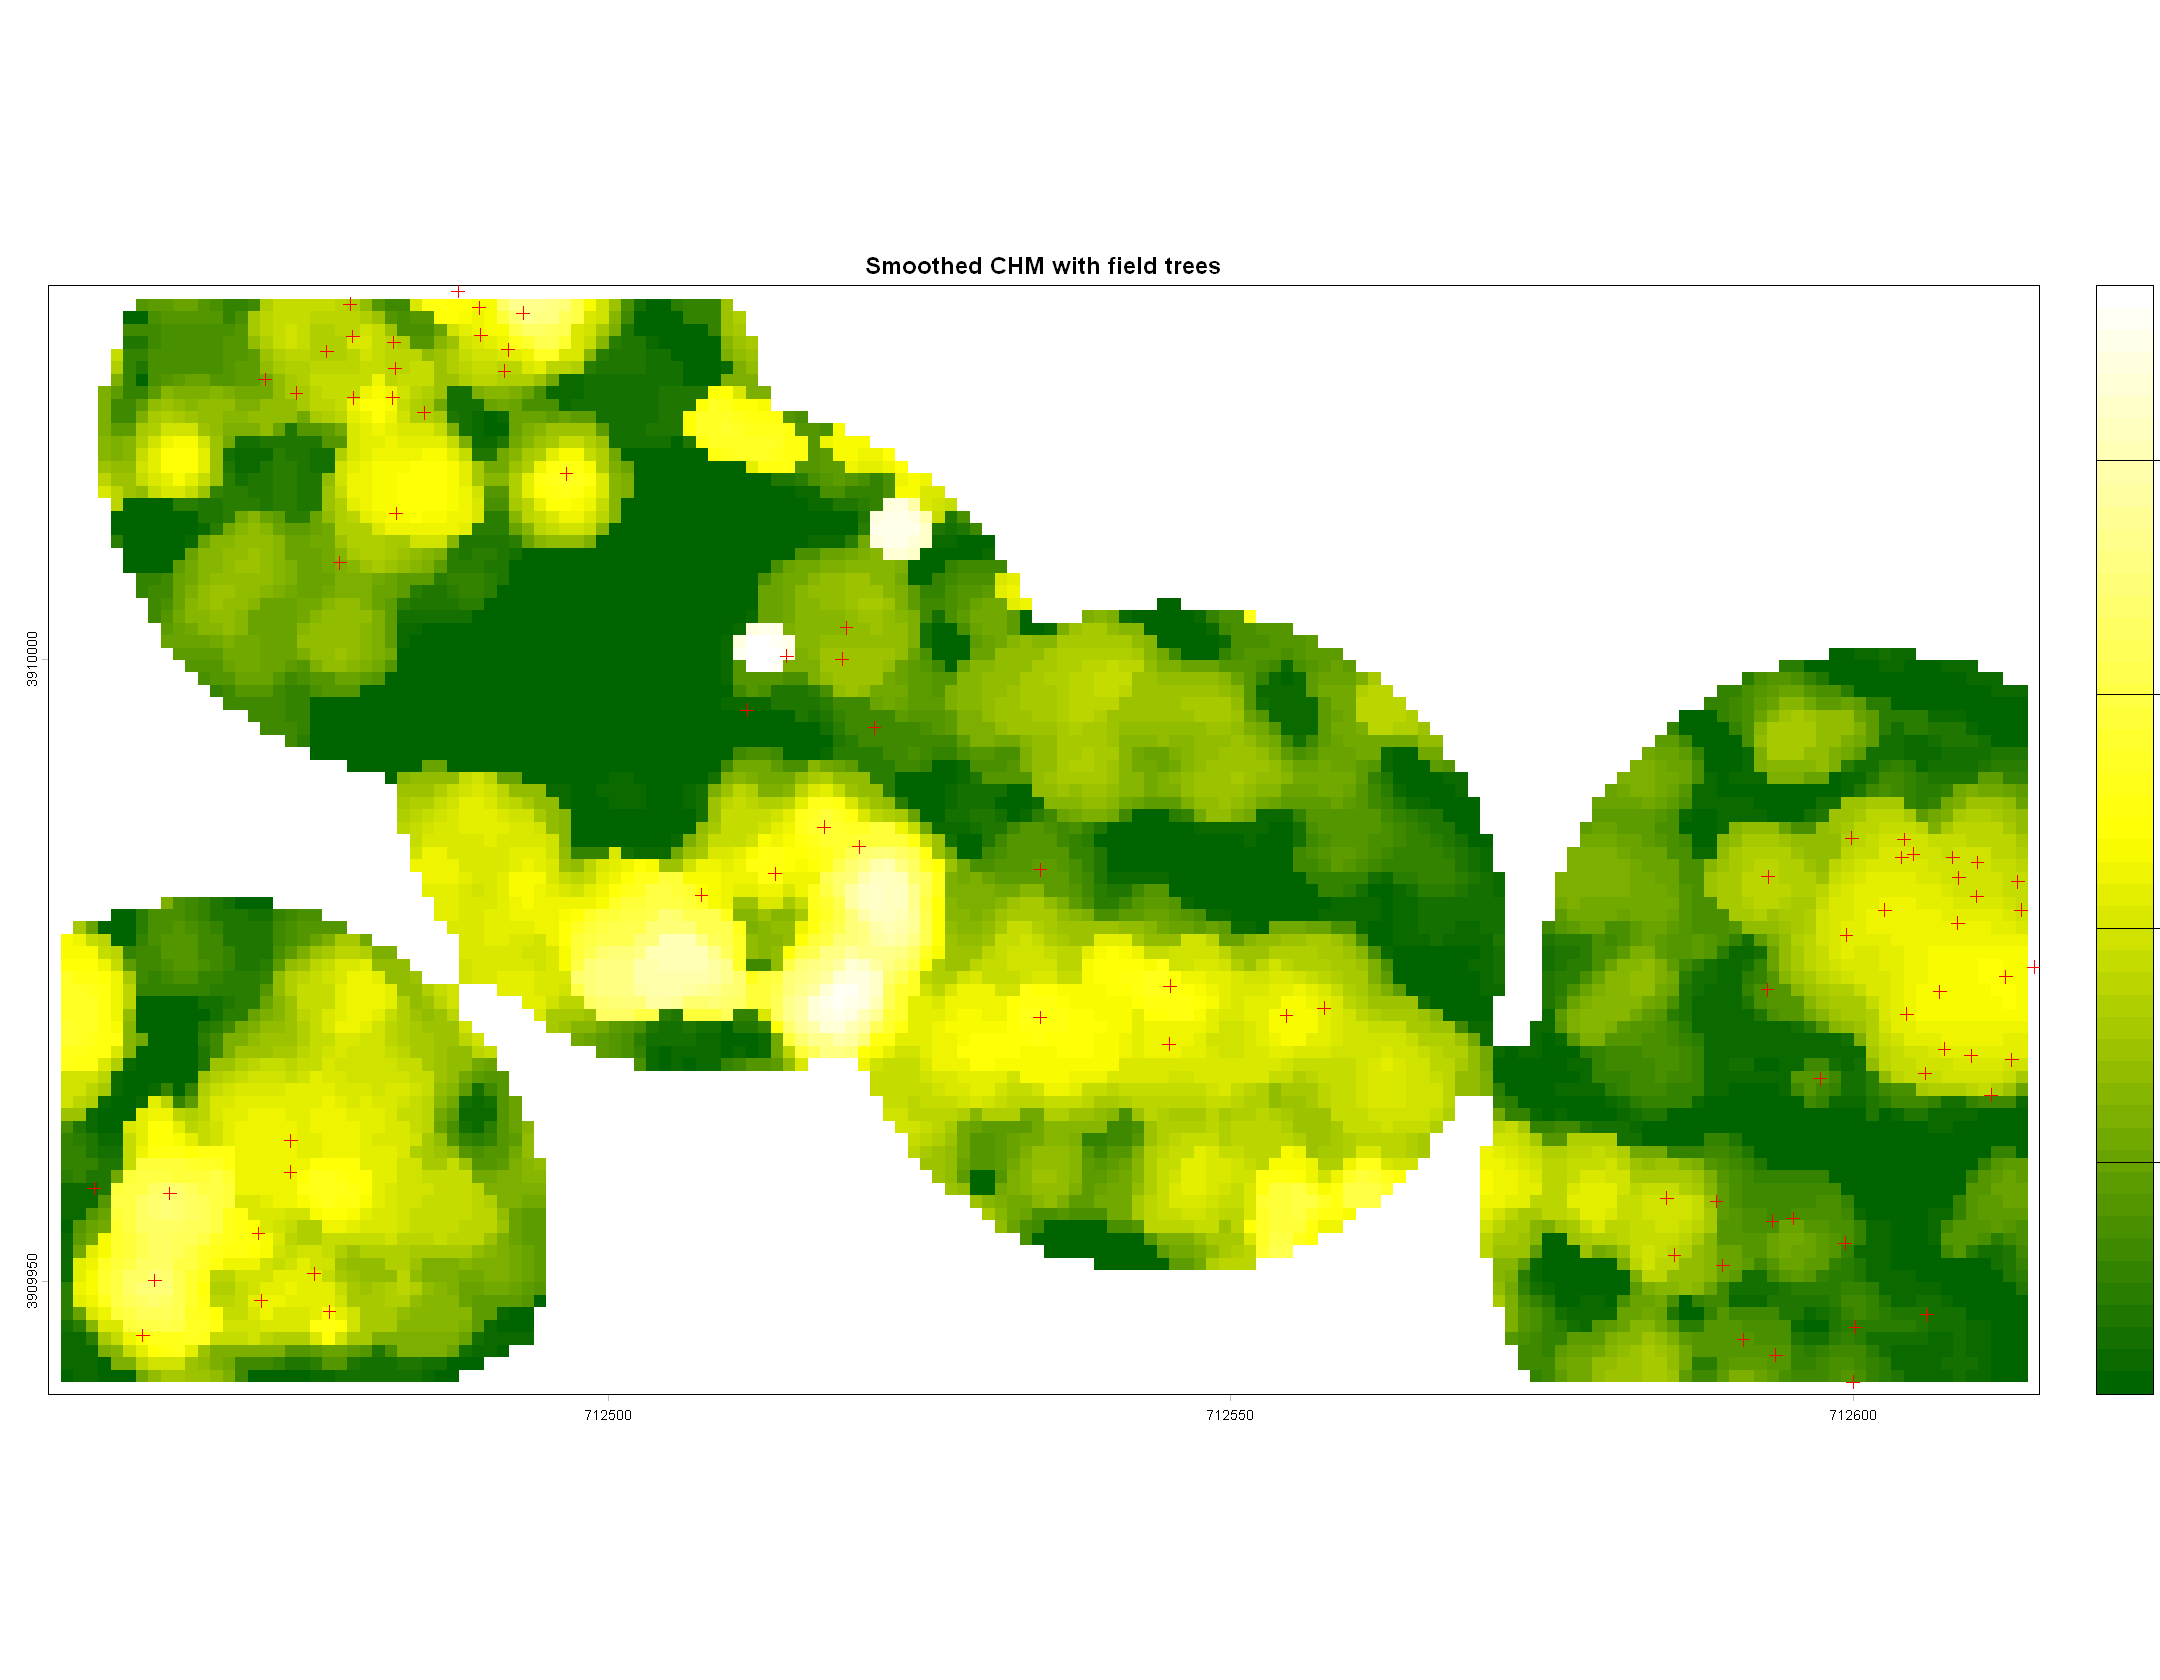

In [39]:
# ── 1. Load and prepare the Canopy Height Model (CHM) ──────────────────────
# The CHM is a raster where each pixel value = height of vegetation above ground
chm <- rast(chm_path)
if (!nzchar(terra::crs(chm))) stop("CHM has no CRS.")

# Reproject footprints to match the CHM's coordinate system
footprints_chm <- st_transform(footprints, crs(chm))

# Crop the CHM to just the bounding box of all footprints combined (faster processing)
chm <- crop(chm, vect(st_union(footprints_chm)), snap = "out")

# Mask the CHM to only keep pixels within 15 m of the footprints (removes irrelevant area)
chm <- mask(chm, vect(st_buffer(st_union(footprints_chm), 15)))

# Smooth the CHM with a 3x3 median filter to reduce noise before tree detection
chm_smooth <- focal(chm, w = 3, fun = median, na.policy = "omit")


# ── 2. Load and clip LiDAR point cloud ─────────────────────────────────────
# A LAScatalog lets you work with large LiDAR files without loading everything into memory
ctg <- readLAScatalog(lidar_path)
if (is.na(st_crs(ctg))) stop("LAS/LAZ has no CRS.")

# Reproject footprints to match the LiDAR CRS
footprints_las_crs <- st_transform(footprints, st_crs(ctg))

# Clip the point cloud to only the footprint polygons (one LAS object per footprint)
las_list <- clip_roi(ctg, footprints_las_crs)

# Combine all per-footprint point clouds into one LAS object
las <- do.call(rbind, las_list)
if (is.empty(las)) stop("LAS/LAZ is empty or unreadable.")


# ── 3. Remove noise points ──────────────────────────────────────────────────
# Statistical Outlier Removal (SOR): flags points that are far from their k=8
# nearest neighbors by more than m=6 standard deviations as noise (class 18)
if (cfg$remove_noise) {
  las <- classify_noise(las, sor(k = 8, m = 6))
  las <- filter_poi(las, Classification != 18L)  # drop flagged noise points
}


# ── 4. Normalize height (Z values) ─────────────────────────────────────────
# Raw LiDAR Z = elevation above sea level; we need Z = height above ground
if (cfg$lidar_is_normalized) {
  # User confirmed Z is already height above ground — use as-is
  las_norm <- las
} else {
  # Classify which returns hit the ground using Cloth Simulation Filter (CSF)
  las_ground <- classify_ground(las, csf())
  
  # Interpolate a Digital Terrain Model (DTM) from ground points
  dtm <- rasterize_terrain(las_ground, cfg$dtm_resolution_m, tin())
  
  # Subtract terrain elevation from all Z values so Z = height above ground
  las_norm <- normalize_height(las_ground, dtm)
}

# Remove returns slightly below ground (small negative Z values are ok,
# but large negatives indicate errors)
las_norm <- filter_poi(las_norm, Z >= -0.5)
cat("Preprocessed returns:", format(npoints(las_norm), big.mark = ","), "\n")


# ── 5. Plot smoothed CHM with field-mapped tree locations ───────────────────
# The blank purple square is likely because chm_smooth has no color scale set.
# Use a proper height color ramp instead:
plot(chm_smooth, main = "Smoothed CHM with field trees",
     col = colorRampPalette(c("darkgreen", "yellow", "white"))(50),
     legend = TRUE)
plot(vect(st_transform(tree_points, crs(chm))), add = TRUE, col = "red", pch = 3)

## 7. Segment trees and calculate H, crown diameter, and LBI

LBI follows the paper's 0.5 m vertical slices above 1 m. Slice area is the area of the Delaunay/convex envelope of points in each slice; LBI is the height-weighted sum of slice areas. Inspect crown geometry before using any biomass results.


Detected crowns: 61  | mapped field trees: 81 


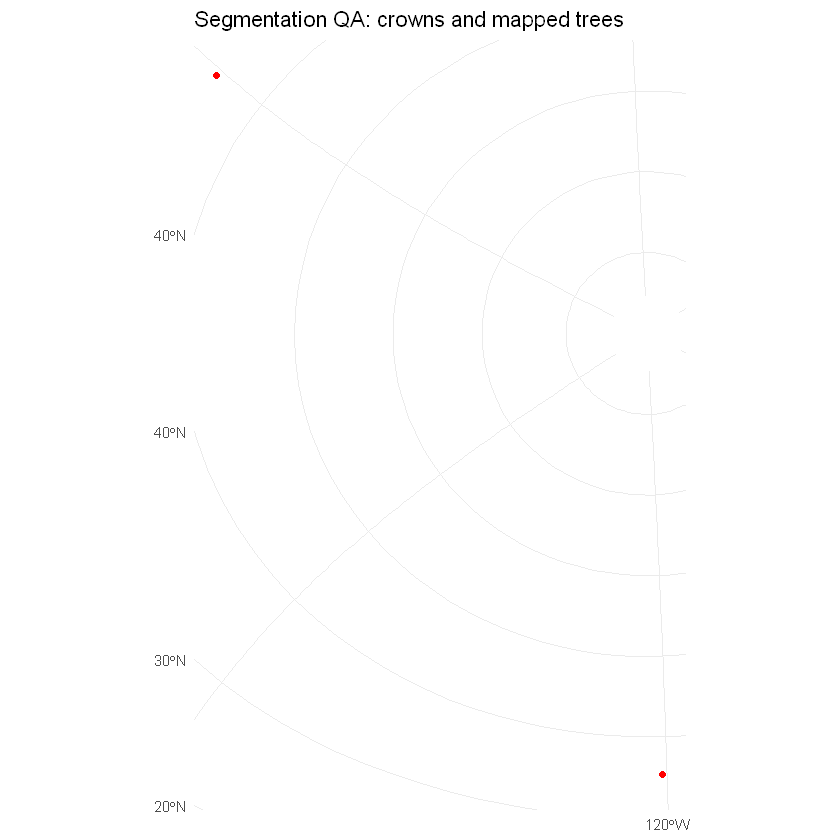

In [29]:
ttops <- locate_trees(chm_smooth, lmf(ws = cfg$treetop_window_m, hmin = cfg$min_tree_height_m))
seg_algorithm <- dalponte2016(
  chm_smooth, ttops, th_tree = cfg$dalponte_th_tree,
  th_seed = cfg$dalponte_th_seed, th_cr = cfg$dalponte_th_cr,
  max_cr = cfg$dalponte_max_cr_m
)
las_segmented <- segment_trees(las_norm, seg_algorithm)
crowns <- crown_metrics(las_segmented, ~list(lidar_height_m = max(Z, na.rm = TRUE)), geom = "convex") |>
  st_make_valid() |>
  mutate(crown_area_m2 = as.numeric(st_area(geometry)), crown_diameter_m = 2 * sqrt(crown_area_m2 / pi))

slice_area <- function(dat) {
  if (nrow(dat) < 3) return(0)
  xy <- unique(dat[, c("X", "Y")])
  if (nrow(xy) < 3) return(0)
  poly <- st_as_sf(xy, coords = c("X", "Y"), crs = st_crs(las_norm)) |>
    st_union() |> st_convex_hull()
  as.numeric(st_area(poly))
}

compute_lbi <- function(dat, bottom_m = 1, dz = 0.5) {
  top <- max(dat$Z, na.rm = TRUE)
  if (!is.finite(top) || top <= bottom_m) return(NA_real_)
  lower <- seq(bottom_m, top, by = dz)
  areas <- map_dbl(lower, function(h) slice_area(dat[dat$Z >= h & dat$Z < h + dz, , drop = FALSE]))
  sum(areas * lower * dz, na.rm = TRUE)
}

segment_data <- as_tibble(las_segmented@data) |>
  filter(!is.na(treeID)) |>
  group_split(treeID)
lbi_table <- map_dfr(segment_data, ~tibble(treeID = first(.x$treeID), LBI = compute_lbi(.x)))
crowns <- crowns |> left_join(lbi_table, by = "treeID")

cat("Detected crowns:", nrow(crowns), " | mapped field trees:", nrow(tree_points), "\n")
ggplot() + geom_sf(data = crowns, fill = NA, colour = "grey40") +
  geom_sf(data = tree_points, colour = "red", size = 1.5) +
  labs(title = "Segmentation QA: crowns and mapped trees") + theme_minimal()


## 8. One-to-one field/LiDAR matching

The Hungarian assignment prevents several field trees from matching the same crown. Cost combines horizontal distance and height disagreement. Matches beyond either threshold are rejected. Review the map and exported match table manually; this is still not equivalent to the paper's manual crown-shape matching.


In [30]:
crown_points <- st_point_on_surface(crowns)
field_for_match <- tree_points |> filter(has_height_reference)
dist_m <- units::drop_units(st_distance(field_for_match, crown_points))
height_diff <- abs(outer(field_for_match$height_manual_m, crowns$lidar_height_m, "-"))
valid_pair <- dist_m <= cfg$match_max_distance_m & height_diff <= cfg$match_max_height_difference_m
cost <- dist_m / cfg$match_max_distance_m + cfg$match_height_weight * height_diff / cfg$match_max_height_difference_m
cost[!valid_pair] <- 1e6

n_square <- max(nrow(cost), ncol(cost))
padded_cost <- matrix(2, n_square, n_square)
padded_cost[seq_len(nrow(cost)), seq_len(ncol(cost))] <- cost
assignment <- as.integer(solve_LSAP(padded_cost))
matched_rows <- tibble(field_row = seq_len(nrow(cost)), crown_row = assignment[seq_len(nrow(cost))]) |>
  filter(crown_row <= ncol(cost)) |>
  mutate(match_valid = map2_lgl(field_row, crown_row, ~valid_pair[.x, .y])) |>
  filter(match_valid)

matches <- matched_rows |>
  transmute(
    tree_id = field_for_match$tree_id[field_row],
    treeID = crowns$treeID[crown_row],
    match_distance_m = dist_m[cbind(field_row, crown_row)],
    height_difference_m = crowns$lidar_height_m[crown_row] - field_for_match$height_manual_m[field_row]
  ) |>
  left_join(st_drop_geometry(tree_reference), by = "tree_id") |>
  left_join(st_drop_geometry(crowns) |> select(treeID, lidar_height_m, crown_area_m2, crown_diameter_m, LBI), by = "treeID")

matching_qc <- tibble(
  field_trees_with_height = nrow(field_for_match), matched = nrow(matches),
  match_rate_pct = 100 * nrow(matches) / nrow(field_for_match),
  height_bias_m = mean(matches$height_difference_m),
  height_rmse_m = sqrt(mean(matches$height_difference_m^2))
)
matching_qc
write_csv(matches, file.path(output_dir, "field_lidar_tree_matches.csv"))


Warning message:
"st_point_on_surface assumes attributes are constant over geometries"


field_trees_with_height,matched,match_rate_pct,height_bias_m,height_rmse_m
<int>,<int>,<dbl>,<dbl>,<dbl>
78,41,52.5641,0.5572683,2.296504


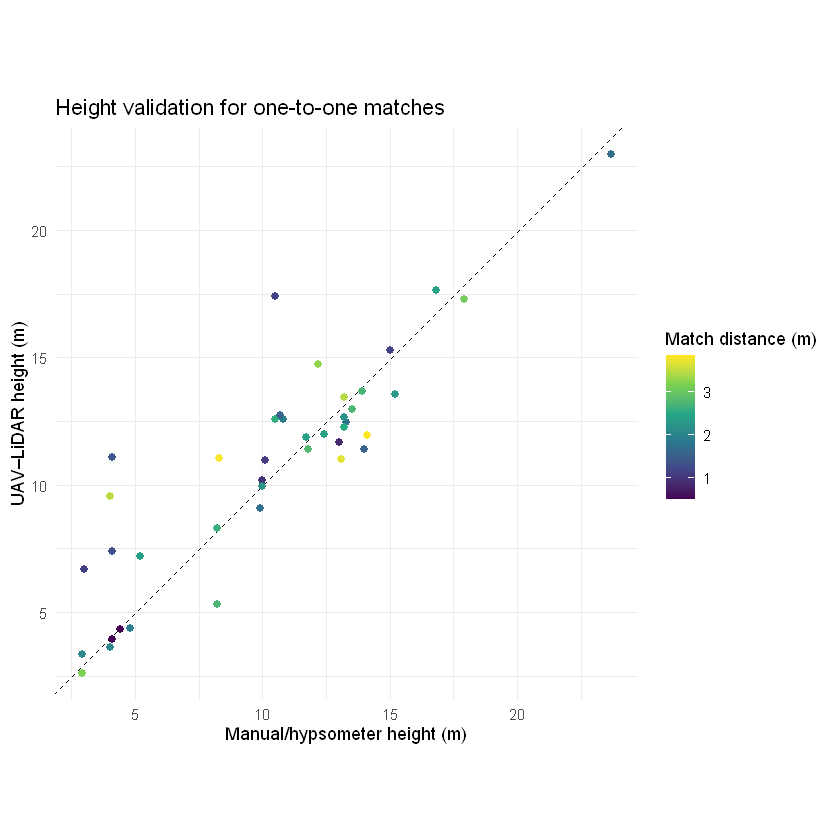

In [31]:
ggplot(matches, aes(x = height_manual_m, y = lidar_height_m, colour = match_distance_m)) +
  geom_abline(slope = 1, intercept = 0, linetype = 2) + geom_point(size = 2) +
  scale_colour_viridis_c() + coord_equal() +
  labs(x = "Manual/hypsometer height (m)", y = "UAV–LiDAR height (m)", colour = "Match distance (m)",
       title = "Height validation for one-to-one matches") + theme_minimal()


## 9. Tree-centric biomass models with footprint-level cross-validation

Two paper-aligned models are fitted only to matched trees with manual biomass:

- local ASM: `ln(Biomass) = α + β ln(H × CD)`
- LBI model: `ln(Biomass) = α + β ln(H) + γ ln(LBI)`

Entire footprints—not individual trees—are left out during cross-validation so trees from the same footprint do not appear in both training and testing sets. A smearing correction is applied after log back-transformation.


In [ ]:
calibration <- matches |>
  filter(has_biomass_reference, biomass_manual_kg > 0, lidar_height_m > 0, crown_diameter_m > 0, LBI > 0,
         footprint_id %in% footprints$footprint_id)
if (nrow(calibration) < 15) stop("Fewer than 15 valid matched biomass trees remain; revise segmentation/matching before modeling.")

fit_log_model <- function(formula, dat) {
  fit <- lm(formula, data = dat)
  list(fit = fit, smear = mean(exp(residuals(fit))))
}
predict_log_model <- function(object, newdata) exp(predict(object$fit, newdata = newdata)) * object$smear

asm_formula <- log(biomass_manual_kg) ~ log(lidar_height_m * crown_diameter_m)
lbi_formula <- log(biomass_manual_kg) ~ log(lidar_height_m) + log(LBI)
asm_model <- fit_log_model(asm_formula, calibration)
lbi_model <- fit_log_model(lbi_formula, calibration)
print(summary(asm_model$fit))
print(summary(lbi_model$fit))

lopo_predict <- function(formula, dat, model_name) {
  map_dfr(unique(dat$footprint_id), function(fp) {
    train <- filter(dat, footprint_id != fp)
    test <- filter(dat, footprint_id == fp)
    model <- fit_log_model(formula, train)
    test |>
      transmute(model = model_name, footprint_id, tree_id,
                observed_kg = biomass_manual_kg, predicted_kg = predict_log_model(model, test))
  })
}
tree_cv <- bind_rows(
  lopo_predict(asm_formula, calibration, "Local ASM"),
  lopo_predict(lbi_formula, calibration, "LBI")
) |>
  mutate(error_kg = predicted_kg - observed_kg)
tree_cv_accuracy <- tree_cv |>
  group_by(model) |>
  summarise(n = n(), bias_kg = mean(error_kg), rmse_kg = sqrt(mean(error_kg^2)),
            rrmse_pct = 100 * rmse_kg / mean(observed_kg),
            pseudo_r2 = 1 - sum(error_kg^2) / sum((observed_kg - mean(observed_kg))^2), .groups = "drop")
tree_cv_accuracy
write_csv(tree_cv, file.path(output_dir, "tree_level_footprint_cv_predictions.csv"))
write_csv(tree_cv_accuracy, file.path(output_dir, "tree_level_cv_accuracy.csv"))


## 10. Predict all segmented trees and aggregate to footprints

This produces a LiDAR estimate for every segmented crown, including trees whose field DBH/biomass was missing. It does not invent a field biomass value for those trees.


In [ ]:
crown_predictions <- crowns |>
  filter(lidar_height_m > 0, crown_diameter_m > 0, LBI > 0)
prediction_data <- st_drop_geometry(crown_predictions)
crown_predictions$pred_asm_kg <- predict_log_model(asm_model, prediction_data)
crown_predictions$pred_lbi_kg <- predict_log_model(lbi_model, prediction_data)
crown_locations <- st_point_on_surface(crown_predictions) |>
  st_join(footprints |> select(footprint_id, area_m2), join = st_within, left = FALSE)

lidar_footprint_biomass <- crown_locations |>
  st_drop_geometry() |>
  group_by(footprint_id, area_m2) |>
  summarise(n_segmented_trees = n(), asm_total_kg = sum(pred_asm_kg), lbi_total_kg = sum(pred_lbi_kg), .groups = "drop") |>
  mutate(asm_Mg_ha = asm_total_kg / area_m2 * 10, lbi_Mg_ha = lbi_total_kg / area_m2 * 10)

reference_completeness <- tree_reference |>
  filter(footprint_id %in% footprints$footprint_id) |>
  group_by(footprint_id) |>
  summarise(n_field_trees = n(), n_with_reference_biomass = sum(has_biomass_reference),
            n_missing_reference_biomass = sum(!has_biomass_reference),
            observed_partial_biomass_kg = sum(biomass_manual_kg, na.rm = TRUE),
            reference_total_complete = all(has_biomass_reference), .groups = "drop")

footprint_results <- lidar_footprint_biomass |>
  left_join(reference_completeness, by = "footprint_id")
footprint_results
write_csv(st_drop_geometry(crown_predictions), file.path(output_dir, "segmented_tree_biomass_predictions.csv"))
write_csv(footprint_results, file.path(output_dir, "footprint_biomass_predictions_and_reference_completeness.csv"))
st_write(crown_predictions, file.path(output_dir, "segmented_tree_biomass.gpkg"), delete_dsn = TRUE, quiet = TRUE)


## 11. Extract paper-aligned footprint metrics

These CHM-, point-, and voxel-based metrics are saved even though an area model is not fitted. They support QA now and make the notebook reusable after more complete independent plots are collected. `lai_proxy` is clearly labeled because the paper did not provide enough implementation detail to reproduce its LAI calculation exactly.


In [ ]:
entropy_1m <- function(z) {
  z <- z[is.finite(z) & z >= 1]
  if (length(z) < 2) return(NA_real_)
  breaks <- seq(floor(min(z)), ceiling(max(z)) + 1, by = 1)
  p <- hist(z, breaks = breaks, plot = FALSE)$counts
  p <- p[p > 0] / sum(p)
  -sum(p * log(p))
}

footprint_metric <- function(cloud, polygon, id) {
  if (is.null(cloud) || is.empty(cloud) || npoints(cloud) < 20) return(tibble(footprint_id = id, extraction_failed = TRUE))
  z <- cloud@data$Z
  chm_clip <- crop(chm, vect(st_transform(polygon, crs(chm))), mask = TRUE)
  cv <- values(chm_clip, mat = FALSE)
  cv <- cv[is.finite(cv)]
  pts <- as_tibble(cloud@data) |>
    filter(is.finite(Z), Z >= 1) |>
    mutate(gx = floor(X), gy = floor(Y)) |>
    group_by(gx, gy) |>
    summarise(hp10 = quantile(Z, 0.10, names = FALSE), hp75 = quantile(Z, 0.75, names = FALSE), .groups = "drop")
  gap <- mean(z < 1, na.rm = TRUE)
  tibble(
    footprint_id = id, extraction_failed = FALSE, n_points = length(z),
    point_density_m2 = length(z) / as.numeric(st_area(polygon)),
    mu_chm = mean(cv, na.rm = TRUE), sigma_chm = sd(cv, na.rm = TRUE), gf_chm_below3 = mean(cv < 3, na.rm = TRUE),
    density_3 = mean(z > 3, na.rm = TRUE), density_6 = mean(z > 6, na.rm = TRUE),
    density_9 = mean(z > 9, na.rm = TRUE), density_12 = mean(z > 12, na.rm = TRUE),
    density_15 = mean(z > 15, na.rm = TRUE), density_18 = mean(z > 18, na.rm = TRUE),
    fhd = entropy_1m(z), lai_proxy = ifelse(gap > 0 & gap < 1, -log(gap) / 0.5, NA_real_),
    mu_hp10 = mean(pts$hp10, na.rm = TRUE), mu_hp75 = mean(pts$hp75, na.rm = TRUE),
    sigma_hp75 = sd(pts$hp75, na.rm = TRUE)
  )
}

footprint_clouds <- clip_roi(las_norm, footprints)
if (!is.list(footprint_clouds)) footprint_clouds <- list(footprint_clouds)
footprint_lidar_metrics <- map2_dfr(footprint_clouds, seq_len(nrow(footprints)),
  ~footprint_metric(.x, footprints[.y, ], footprints$footprint_id[.y]))
if (max(footprint_lidar_metrics$point_density_m2, na.rm = TRUE) / min(footprint_lidar_metrics$point_density_m2, na.rm = TRUE) > 1.5) {
  warning("Point density varies by more than 50% among footprints; density standardization should be investigated.")
}
write_csv(footprint_lidar_metrics, file.path(output_dir, "footprint_lidar_metrics.csv"))
footprint_lidar_metrics


## 12. Area-based and object-based decision gates

The paper's area-based models were calibrated on 23 and 52 complete plots. Here there are only six footprints, and the workbook currently has missing manual biomass in multiple footprints. The code below reports whether area-based calibration is permissible; it does not fit a misleading model.

Object-based calibration also remains gated. It requires coarse multi-tree objects plus a reviewed list of which field trees belong to each object. Dividing a footprint biomass total among objects would create circular pseudo-labels.


In [ ]:
area_model_gate <- reference_completeness |>
  summarise(
    n_footprints = n(),
    n_complete_reference_totals = sum(reference_total_complete),
    all_reference_totals_complete = all(reference_total_complete),
    enough_plots_for_exploratory_one_predictor_model = n() >= 10,
    enough_plots_for_paper_style_feature_selection = n() >= 25
  )
area_model_gate
if (!area_model_gate$all_reference_totals_complete) {
  message("AREA MODEL NOT FIT: at least one footprint total is a partial biomass sum.")
} else if (!area_model_gate$enough_plots_for_exploratory_one_predictor_model) {
  message("AREA MODEL NOT FIT: six complete plots are still too few for defensible calibration.")
}


## 13. Optional AOI prediction and reproducibility record

A wall-to-wall AOI map should only be generated after crown segmentation and held-out footprint performance are acceptable. The same fitted tree model can then be applied to all segmented crowns within the AOI. Cells outside the range of calibration heights, crown diameters, or LBI values should be flagged as extrapolation.


In [ ]:
write_csv(selected_inputs, file.path(output_dir, "selected_inputs.csv"))
write_csv(st_drop_geometry(tree_points), file.path(output_dir, "standardized_mapped_tree_reference.csv"))
writeLines(capture.output(sessionInfo()), file.path(output_dir, "sessionInfo.txt"))
cat("Outputs written to:", normalizePath(output_dir, winslash = "/", mustWork = TRUE), "\n")
sessionInfo()
